# 04 — Autopsia del Modelo: "Dónde Falla y Por Qué"

---

## Misión

Tu modelo dice 96% accuracy. Suena genial.

Pero ese 4% de error son ~23 diagnósticos equivocados. Si la mitad son Falsos Negativos, son **~12 pacientes con cáncer que tu modelo dijo que estaban sanos**.

Eso es inaceptable.

## El costo asimétrico de los errores

No todos los errores son iguales:

| Error | Significado | Consecuencia | Costo |
|---|---|---|---|
| **FP** (Falso Positivo) | Le dices a alguien sano que puede tener cáncer | Biopsia innecesaria, ansiedad | ~$2,000 + estrés |
| **FN** (Falso Negativo) | Le dices a alguien con cáncer que está sano | Diagnóstico tardío, posible metástasis | **Incalculable** |

### Analogía del detector de humo

**Prefieres que suene 10 veces de más a que no suene cuando hay fuego.**

En medicina: mejor 10 biopsias innecesarias que 1 cáncer no detectado.

Esto significa que **Recall para Maligno es nuestra métrica sagrada**.

## 1. Imports y carga de datos

In [1]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import learning_curve, StratifiedKFold

plt.style.use('seaborn-v0_8-whitegrid')
COLOR_B = '#2ecc71'
COLOR_M = '#e74c3c'

print("Imports OK")

Imports OK


In [2]:
# Cargar datos procesados
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
processed_dir = os.path.join(project_root, "data", "breast_cancer", "processed")

X_train = pd.read_parquet(os.path.join(processed_dir, "X_train.parquet"))
X_test = pd.read_parquet(os.path.join(processed_dir, "X_test.parquet"))
y_train = pd.read_parquet(os.path.join(processed_dir, "y_train.parquet")).values.ravel()
y_test = pd.read_parquet(os.path.join(processed_dir, "y_test.parquet")).values.ravel()

print(f"Test set: {X_test.shape[0]} muestras, {X_test.shape[1]} features")
print(f"Distribución test: B={np.sum(y_test==0)}, M={np.sum(y_test==1)}")

Test set: 114 muestras, 23 features
Distribución test: B=72, M=42


In [3]:
# Cargar modelos guardados
models_dir = os.path.join(project_root, "models", "breast_cancer")

lr = joblib.load(os.path.join(models_dir, "logistic_regression.joblib"))
rf = joblib.load(os.path.join(models_dir, "random_forest.joblib"))
xgb = joblib.load(os.path.join(models_dir, "xgboost.joblib"))

model_dict = {
    'Logistic Regression': lr,
    'Random Forest': rf,
    'XGBoost': xgb,
}

print("Modelos cargados:")
for name in model_dict:
    print(f"  - {name}")

Modelos cargados:
  - Logistic Regression
  - Random Forest
  - XGBoost


In [4]:
# Generar predicciones y probabilidades
predictions = {}
probabilities = {}

for name, model in model_dict.items():
    predictions[name] = model.predict(X_test)
    probabilities[name] = model.predict_proba(X_test)[:, 1]

print("Predicciones generadas.")

Predicciones generadas.


---

## 2. Matrices de confusión — Vista comparativa

Tres modelos, lado a lado. El número que nos quita el sueño: **FN** (esquina inferior izquierda).

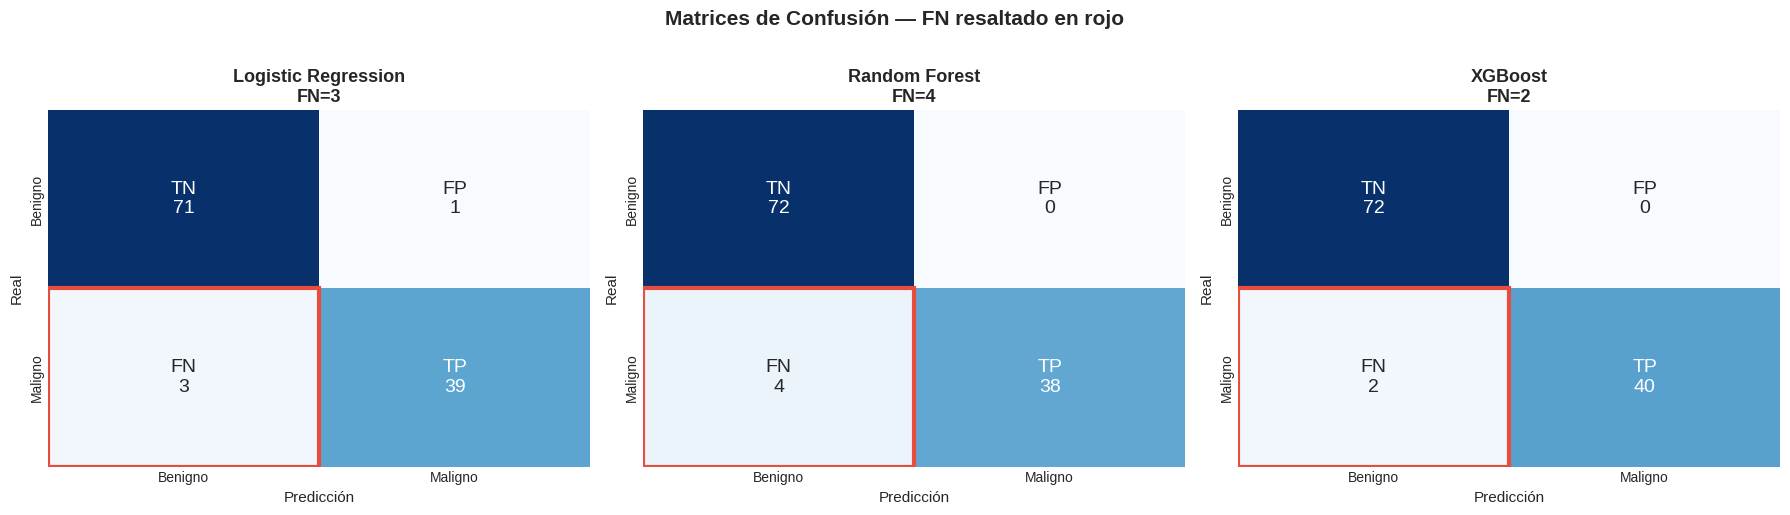

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    
    # Crear anotaciones con etiquetas
    labels = np.array([
        [f'TN\n{cm[0,0]}', f'FP\n{cm[0,1]}'],
        [f'FN\n{cm[1,0]}', f'TP\n{cm[1,1]}']
    ])
    
    sns.heatmap(
        cm, annot=labels, fmt='',
        cmap='Blues',
        xticklabels=['Benigno', 'Maligno'],
        yticklabels=['Benigno', 'Maligno'],
        ax=ax, cbar=False,
        annot_kws={'size': 14}
    )
    
    # Resaltar celda FN con borde rojo
    ax.add_patch(plt.Rectangle((0, 1), 1, 1, fill=False, edgecolor=COLOR_M, linewidth=3))
    
    ax.set_xlabel('Predicción', fontsize=11)
    ax.set_ylabel('Real', fontsize=11)
    ax.set_title(f'{name}\nFN={cm[1,0]}', fontsize=13, fontweight='bold')

plt.suptitle('Matrices de Confusión — FN resaltado en rojo', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## 3. Análisis de Falsos Negativos

¿Qué tienen estos tumores malignos que el modelo confunde con benignos?

Vamos a extraer los FN de cada modelo y estudiar sus características.

In [6]:
# Contar FN por modelo
fn_summary = {}
for name, y_pred in predictions.items():
    fn_mask = (y_test == 1) & (y_pred == 0)
    fn_count = fn_mask.sum()
    fn_summary[name] = fn_count
    print(f"{name}: {fn_count} Falsos Negativos")

best_model_name = min(fn_summary, key=fn_summary.get)
print(f"\nMejor modelo (menos FN): {best_model_name} con {fn_summary[best_model_name]} FN")

Logistic Regression: 3 Falsos Negativos
Random Forest: 4 Falsos Negativos
XGBoost: 2 Falsos Negativos

Mejor modelo (menos FN): XGBoost con 2 FN


In [7]:
# Extraer casos FN del mejor modelo para análisis detallado
y_pred_best = predictions[best_model_name]
fn_mask = (y_test == 1) & (y_pred_best == 0)
tp_mask = (y_test == 1) & (y_pred_best == 1)
tn_mask = (y_test == 0) & (y_pred_best == 0)

X_test_fn = X_test[fn_mask]
X_test_tp = X_test[tp_mask]
X_test_tn = X_test[tn_mask]

print(f"Casos FN: {len(X_test_fn)}")
print(f"Casos TP (Maligno correcto): {len(X_test_tp)}")
print(f"Casos TN (Benigno correcto): {len(X_test_tn)}")

Casos FN: 2
Casos TP (Maligno correcto): 40
Casos TN (Benigno correcto): 72


In [8]:
# Comparar estadísticas: FN vs TP vs TN
if len(X_test_fn) > 0:
    comparison = pd.DataFrame({
        'FN (Maligno no detectado)': X_test_fn.mean(),
        'TP (Maligno detectado)': X_test_tp.mean(),
        'TN (Benigno correcto)': X_test_tn.mean(),
    })
    
    # Mostrar las 10 features con mayor diferencia entre FN y TP
    comparison['diff_FN_vs_TP'] = abs(comparison['FN (Maligno no detectado)'] - comparison['TP (Maligno detectado)'])
    top_diff = comparison.nlargest(10, 'diff_FN_vs_TP')
    
    print("Top 10 features donde FN difiere más de TP:")
    print(top_diff[['FN (Maligno no detectado)', 'TP (Maligno detectado)', 'TN (Benigno correcto)']].round(3))
else:
    print("No hay Falsos Negativos. El modelo detecta todos los casos malignos.")

Top 10 features donde FN difiere más de TP:
                     FN (Maligno no detectado)  TP (Maligno detectado)  \
texture_se                              -1.317                   0.036   
texture_worst                           -0.882                   0.455   
texture_mean                            -0.743                   0.466   
concave_points_se                       -0.471                   0.652   
concavity_mean                          -0.153                   0.895   
radius_se                               -0.470                   0.568   
concave_points_mean                     -0.083                   0.946   
symmetry_mean                           -0.677                   0.346   
compactness_se                          -0.307                   0.542   
symmetry_se                             -0.808                   0.034   

                     TN (Benigno correcto)  
texture_se                           0.002  
texture_worst                       -0.525  
textur

### Scatter: FN cerca de la frontera de decisión

Los FN son tumores malignos que "parecen benignos". Veamos dónde caen en las dos features más importantes.

In [9]:
# Obtener las 2 features más importantes del Random Forest
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
top2_features = importances.nlargest(2).index.tolist()
feat_x, feat_y = top2_features[0], top2_features[1]

print(f"Top 2 features: {feat_x}, {feat_y}")

Top 2 features: perimeter_worst, concave_points_worst


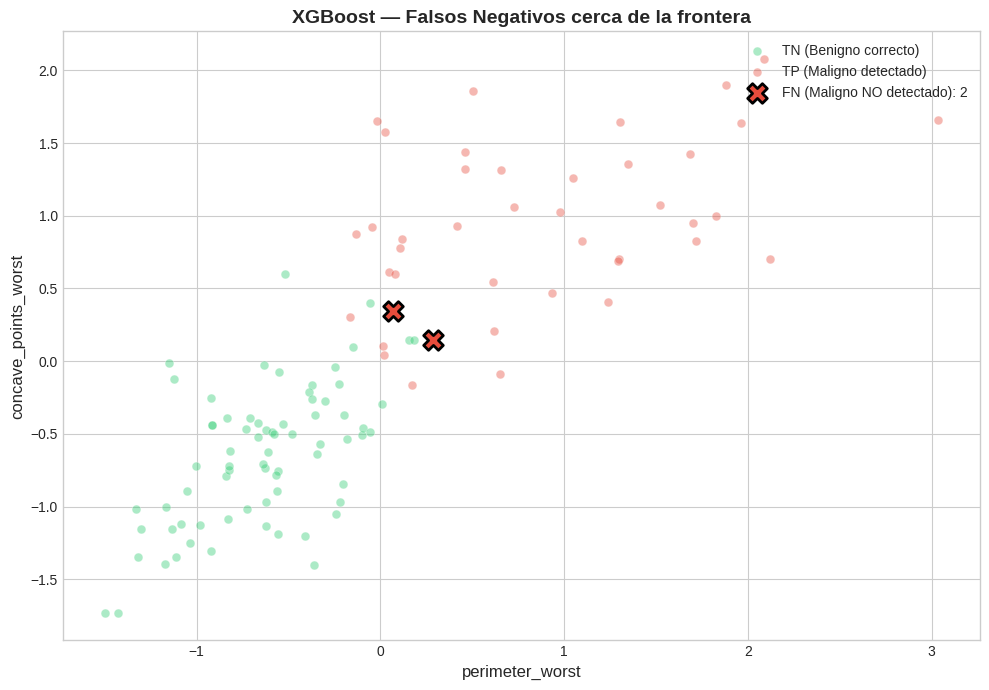

In [10]:
fig, ax = plt.subplots(figsize=(10, 7))

# Benignos correctos (TN)
ax.scatter(
    X_test_tn[feat_x], X_test_tn[feat_y],
    c=COLOR_B, alpha=0.4, s=40, label='TN (Benigno correcto)', edgecolors='white', linewidth=0.5
)

# Malignos correctos (TP)
ax.scatter(
    X_test_tp[feat_x], X_test_tp[feat_y],
    c=COLOR_M, alpha=0.4, s=40, label='TP (Maligno detectado)', edgecolors='white', linewidth=0.5
)

# Falsos Negativos — grandes, con borde negro
if len(X_test_fn) > 0:
    ax.scatter(
        X_test_fn[feat_x], X_test_fn[feat_y],
        c=COLOR_M, s=200, marker='X', edgecolors='black', linewidth=2,
        label=f'FN (Maligno NO detectado): {len(X_test_fn)}', zorder=5
    )

ax.set_xlabel(feat_x, fontsize=12)
ax.set_ylabel(feat_y, fontsize=12)
ax.set_title(
    f'{best_model_name} — Falsos Negativos cerca de la frontera',
    fontsize=14, fontweight='bold'
)
ax.legend(fontsize=10, loc='upper right')
plt.tight_layout()
plt.show()

In [11]:
# Probabilidades de los FN: ¿qué tan "seguros" estaba el modelo de que eran benignos?
proba_best = probabilities[best_model_name]

if fn_mask.sum() > 0:
    fn_probas = proba_best[fn_mask]
    print(f"Probabilidades asignadas a los FN (P(Maligno)):")
    for i, p in enumerate(fn_probas):
        print(f"  Caso {i+1}: {p:.4f}  {'← Casi en la frontera (0.5)' if 0.3 < p < 0.7 else '← Lejos de la frontera'}")
    print(f"\nMedia: {fn_probas.mean():.4f}")
    print(f"Umbral actual: 0.50")
    print(f"\nSi bajamos el umbral a 0.30, ¿cuántos FN rescatamos? {(fn_probas >= 0.30).sum()}/{len(fn_probas)}")
    print(f"Si bajamos el umbral a 0.20, ¿cuántos FN rescatamos? {(fn_probas >= 0.20).sum()}/{len(fn_probas)}")
else:
    print("No hay FN para analizar.")

Probabilidades asignadas a los FN (P(Maligno)):
  Caso 1: 0.0063  ← Lejos de la frontera
  Caso 2: 0.2076  ← Lejos de la frontera

Media: 0.1070
Umbral actual: 0.50

Si bajamos el umbral a 0.30, ¿cuántos FN rescatamos? 0/2
Si bajamos el umbral a 0.20, ¿cuántos FN rescatamos? 1/2


---

## 4. Classification Report detallado

Métricas por clase para cada modelo.

In [12]:
for name, y_pred in predictions.items():
    print(f"{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(classification_report(y_test, y_pred, target_names=['Benigno (0)', 'Maligno (1)']))
    print()

  Logistic Regression
              precision    recall  f1-score   support

 Benigno (0)       0.96      0.99      0.97        72
 Maligno (1)       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114


  Random Forest
              precision    recall  f1-score   support

 Benigno (0)       0.95      1.00      0.97        72
 Maligno (1)       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114


  XGBoost
              precision    recall  f1-score   support

 Benigno (0)       0.97      1.00      0.99        72
 Maligno (1)       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98 

---

## 5. Feature Importance — ¿Los modelos coinciden?

Si los tres modelos consideran importantes las mismas features, hay señal real.

Si no coinciden, cada uno está capturando patrones diferentes.

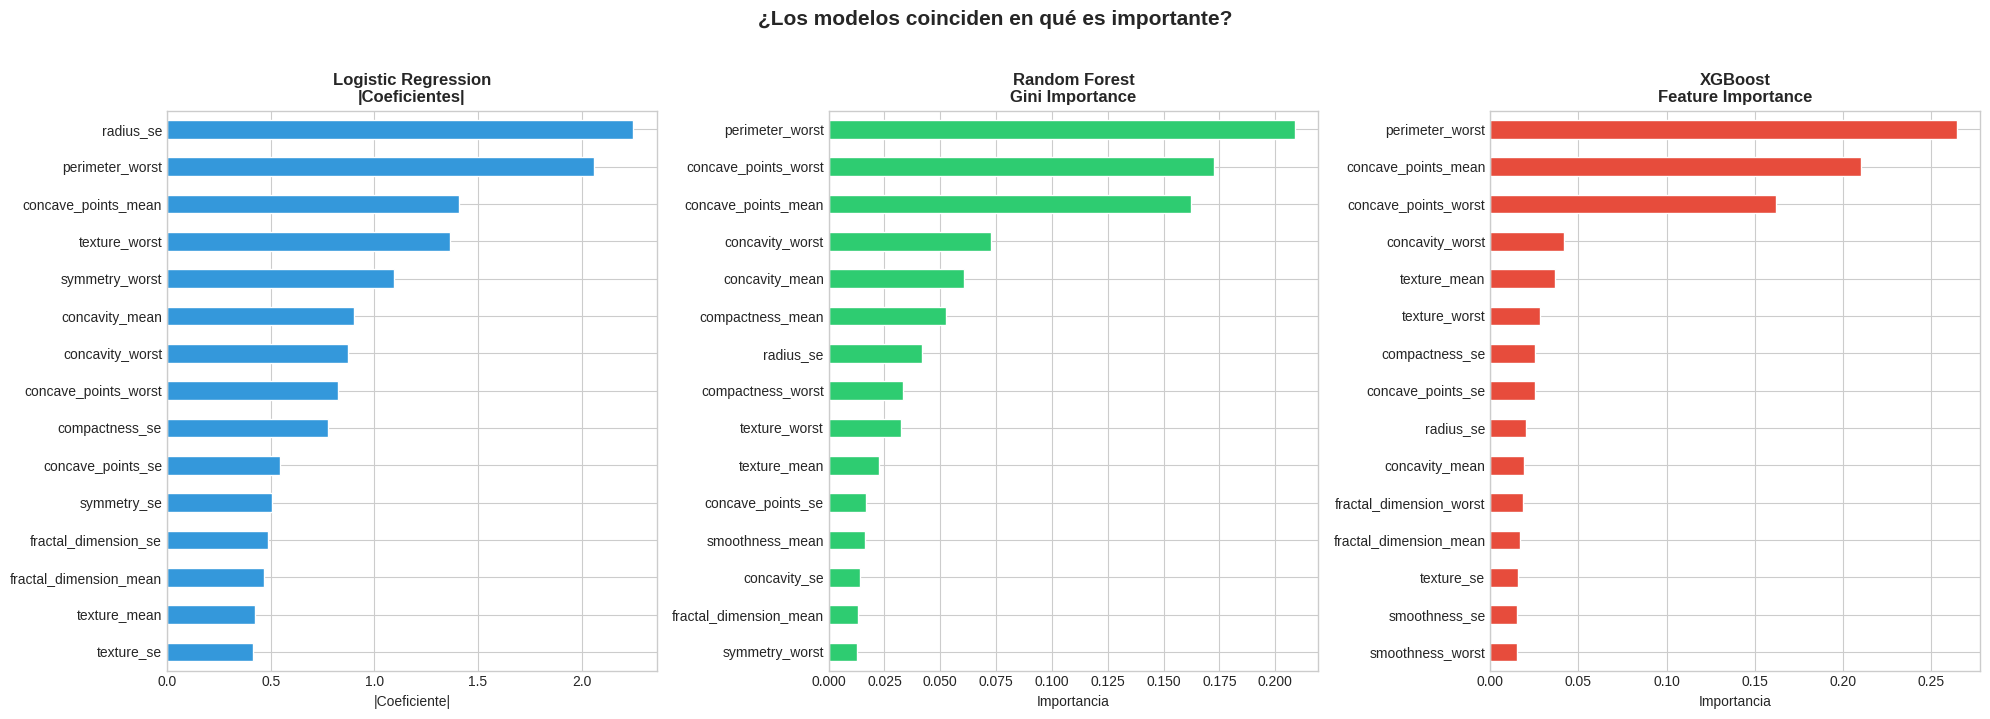

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
colors = ['#3498db', '#2ecc71', '#e74c3c']

# Logistic Regression: coeficientes absolutos
lr_imp = pd.Series(np.abs(lr.coef_[0]), index=X_train.columns)
lr_top15 = lr_imp.nlargest(15)
lr_top15.sort_values().plot.barh(ax=axes[0], color=colors[0], edgecolor='white')
axes[0].set_title('Logistic Regression\n|Coeficientes|', fontsize=12, fontweight='bold')
axes[0].set_xlabel('|Coeficiente|')

# Random Forest: importancia de Gini
rf_imp = pd.Series(rf.feature_importances_, index=X_train.columns)
rf_top15 = rf_imp.nlargest(15)
rf_top15.sort_values().plot.barh(ax=axes[1], color=colors[1], edgecolor='white')
axes[1].set_title('Random Forest\nGini Importance', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Importancia')

# XGBoost: importancia
xgb_imp = pd.Series(xgb.feature_importances_, index=X_train.columns)
xgb_top15 = xgb_imp.nlargest(15)
xgb_top15.sort_values().plot.barh(ax=axes[2], color=colors[2], edgecolor='white')
axes[2].set_title('XGBoost\nFeature Importance', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Importancia')

plt.suptitle('¿Los modelos coinciden en qué es importante?', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [14]:
# ¿Cuántas features del top 10 comparten?
lr_top10 = set(lr_imp.nlargest(10).index)
rf_top10 = set(rf_imp.nlargest(10).index)
xgb_top10 = set(xgb_imp.nlargest(10).index)

common_all = lr_top10 & rf_top10 & xgb_top10
common_lr_rf = lr_top10 & rf_top10
common_lr_xgb = lr_top10 & xgb_top10
common_rf_xgb = rf_top10 & xgb_top10

print(f"Features en top 10 de LOS 3 modelos ({len(common_all)}): {sorted(common_all)}")
print(f"\nLR ∩ RF ({len(common_lr_rf)}): {sorted(common_lr_rf)}")
print(f"LR ∩ XGB ({len(common_lr_xgb)}): {sorted(common_lr_xgb)}")
print(f"RF ∩ XGB ({len(common_rf_xgb)}): {sorted(common_rf_xgb)}")

Features en top 10 de LOS 3 modelos (7): ['concave_points_mean', 'concave_points_worst', 'concavity_mean', 'concavity_worst', 'perimeter_worst', 'radius_se', 'texture_worst']

LR ∩ RF (7): ['concave_points_mean', 'concave_points_worst', 'concavity_mean', 'concavity_worst', 'perimeter_worst', 'radius_se', 'texture_worst']
LR ∩ XGB (9): ['compactness_se', 'concave_points_mean', 'concave_points_se', 'concave_points_worst', 'concavity_mean', 'concavity_worst', 'perimeter_worst', 'radius_se', 'texture_worst']
RF ∩ XGB (8): ['concave_points_mean', 'concave_points_worst', 'concavity_mean', 'concavity_worst', 'perimeter_worst', 'radius_se', 'texture_mean', 'texture_worst']


---

## 6. Curvas de aprendizaje

¿Más datos ayudarían? Si la curva de validación sigue subiendo, sí. Si se estancó, necesitas un modelo diferente.

In [15]:
best_model = model_dict[best_model_name]
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=skf,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

print(f"Curva calculada para: {best_model_name}")

Curva calculada para: XGBoost


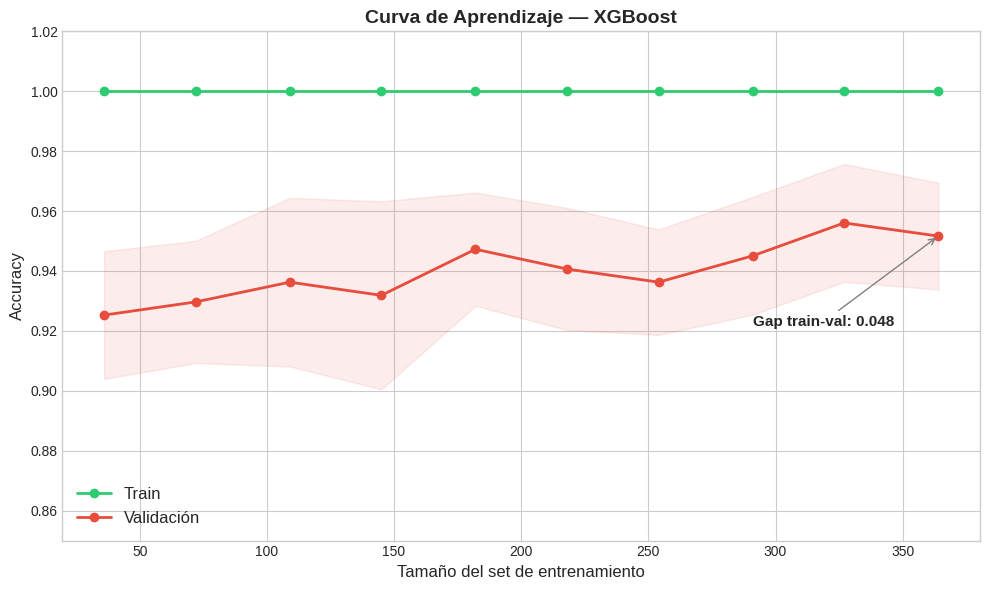

Buen balance. La curva se estabiliza → más datos probablemente no ayuden mucho.
Siguiente paso: optimizar el umbral de decisión.


In [16]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color=COLOR_B)
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color=COLOR_M)

ax.plot(train_sizes, train_mean, 'o-', color=COLOR_B, label='Train', linewidth=2)
ax.plot(train_sizes, val_mean, 'o-', color=COLOR_M, label='Validación', linewidth=2)

ax.set_xlabel('Tamaño del set de entrenamiento', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title(f'Curva de Aprendizaje — {best_model_name}', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.set_ylim(0.85, 1.02)

# Diagnóstico
gap = train_mean[-1] - val_mean[-1]
ax.annotate(
    f'Gap train-val: {gap:.3f}',
    xy=(train_sizes[-1], val_mean[-1]),
    xytext=(train_sizes[-3], val_mean[-1] - 0.03),
    fontsize=11, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='gray'),
)

plt.tight_layout()
plt.show()

if gap > 0.05:
    print("Gap alto → OVERFITTING. Más datos podrían ayudar, o simplificar el modelo.")
elif val_mean[-1] < 0.95:
    print("Validación baja → UNDERFITTING. Necesitas un modelo más complejo o mejores features.")
else:
    print("Buen balance. La curva se estabiliza → más datos probablemente no ayuden mucho.")
    print("Siguiente paso: optimizar el umbral de decisión.")

---

## 7. Análisis de error por rango de features

¿En qué rangos de las features más importantes comete más errores el modelo?

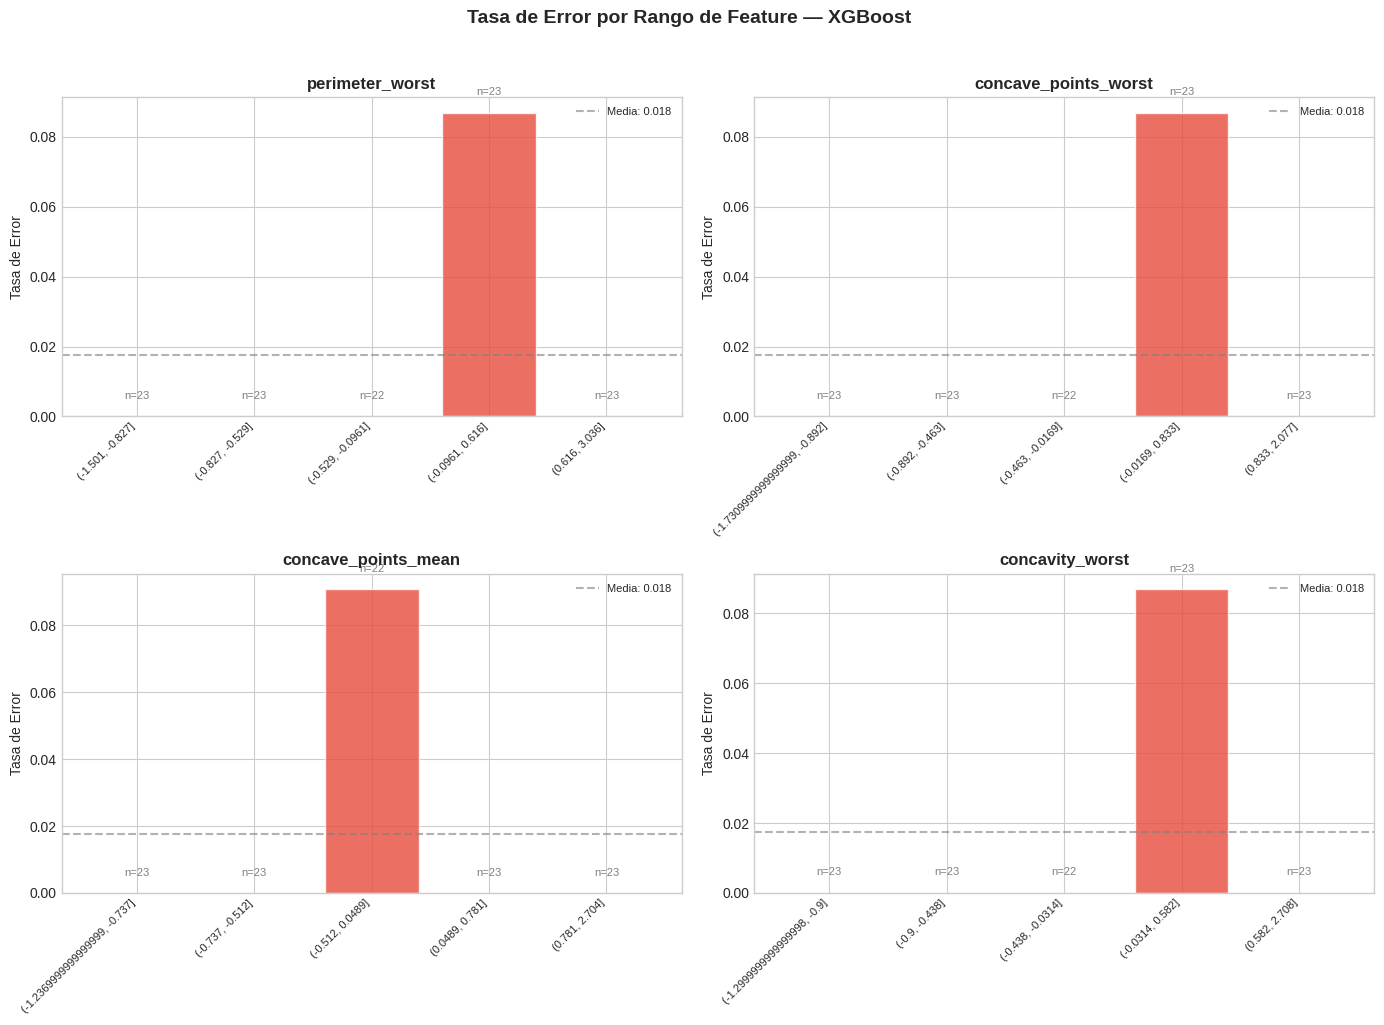

In [17]:
# Top 4 features más importantes (del Random Forest)
top4_features = importances.nlargest(4).index.tolist()

y_pred_best = predictions[best_model_name]
errors = (y_test != y_pred_best).astype(int)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, feat in zip(axes.ravel(), top4_features):
    # Crear bins
    feat_values = X_test[feat]
    bins = pd.qcut(feat_values, q=5, duplicates='drop')
    
    error_by_bin = pd.DataFrame({
        'bin': bins,
        'error': errors,
        'count': 1
    }).groupby('bin', observed=True).agg(
        error_rate=('error', 'mean'),
        n_samples=('count', 'sum')
    )
    
    # Barras de error rate
    bar_colors = [COLOR_M if er > errors.mean() else COLOR_B for er in error_by_bin['error_rate']]
    bars = ax.bar(
        range(len(error_by_bin)),
        error_by_bin['error_rate'],
        color=bar_colors,
        edgecolor='white',
        alpha=0.8
    )
    
    # Etiquetas
    ax.set_xticks(range(len(error_by_bin)))
    ax.set_xticklabels([str(b) for b in error_by_bin.index], rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Tasa de Error', fontsize=10)
    ax.set_title(feat, fontsize=12, fontweight='bold')
    ax.axhline(y=errors.mean(), color='gray', linestyle='--', alpha=0.6, label=f'Media: {errors.mean():.3f}')
    ax.legend(fontsize=8)
    
    # N muestras encima de cada barra
    for i, (er, n) in enumerate(zip(error_by_bin['error_rate'], error_by_bin['n_samples'])):
        ax.text(i, er + 0.005, f'n={n}', ha='center', fontsize=8, color='gray')

plt.suptitle(
    f'Tasa de Error por Rango de Feature — {best_model_name}',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

Los bins en rojo tienen tasa de error superior a la media. Estos son los rangos donde el modelo tiene más dificultad para clasificar correctamente.

---

## 8. Resumen de la autopsia

In [18]:
print("=" * 65)
print("  AUTOPSIA DEL MODELO — RESUMEN")
print("=" * 65)

print("\n--- Falsos Negativos por modelo ---")
for name, fn_count in fn_summary.items():
    marker = " ← MEJOR" if name == best_model_name else ""
    print(f"  {name}: {fn_count} FN{marker}")

print(f"\n--- Modelo con menos FN: {best_model_name} ---")

if fn_mask.sum() > 0:
    print(f"\n--- Perfil de los FN ---")
    print(f"  Son tumores malignos con valores atípicamente bajos en features clave.")
    print(f"  Parecen benignos en las dimensiones más discriminativas.")
    print(f"  Probabilidades cerca de 0.5 → están en la zona de incertidumbre.")
else:
    print(f"\n  Sin Falsos Negativos en el test set (resultado ideal).")

print(f"\n--- Features importantes ---")
print(f"  Los 3 modelos coinciden en {len(common_all)} features del top 10.")

print(f"\n--- Curva de aprendizaje ---")
print(f"  Gap train-validación: {gap:.3f}")
if gap > 0.05:
    print(f"  Diagnóstico: Overfitting moderado.")
else:
    print(f"  Diagnóstico: Buen balance, curva estabilizada.")

print(f"\n{'=' * 65}")
print(f"  SIGUIENTE PASO: Manipular el umbral de decisión.")
print(f"  Bajar el umbral de 0.5 a ~0.3 para rescatar FN")
print(f"  a costa de más FP (biopsias innecesarias → aceptable).")
print(f"{'=' * 65}")

  AUTOPSIA DEL MODELO — RESUMEN

--- Falsos Negativos por modelo ---
  Logistic Regression: 3 FN
  Random Forest: 4 FN
  XGBoost: 2 FN ← MEJOR

--- Modelo con menos FN: XGBoost ---

--- Perfil de los FN ---
  Son tumores malignos con valores atípicamente bajos en features clave.
  Parecen benignos en las dimensiones más discriminativas.
  Probabilidades cerca de 0.5 → están en la zona de incertidumbre.

--- Features importantes ---
  Los 3 modelos coinciden en 7 features del top 10.

--- Curva de aprendizaje ---
  Gap train-validación: 0.048
  Diagnóstico: Buen balance, curva estabilizada.

  SIGUIENTE PASO: Manipular el umbral de decisión.
  Bajar el umbral de 0.5 a ~0.3 para rescatar FN
  a costa de más FP (biopsias innecesarias → aceptable).


---

## Conclusión

### Lo que descubrimos

1. **Los FN son tumores malignos que parecen benignos** — valores bajos en las features clave
2. **Los modelos coinciden** en qué features importan — hay señal real
3. **La curva de aprendizaje** sugiere que más datos no ayudarían mucho
4. **Los errores se concentran** en rangos específicos de las features

### Lo que necesitamos hacer

**Manipular el umbral de decisión.** El umbral por defecto (0.5) trata FP y FN como igualmente malos. Pero en diagnóstico médico, un FN es catastrófico.

Bajando el umbral: más FP (biopsias extras) pero menos FN (menos cáncer sin detectar).

**Siguiente notebook: Optimización del umbral y evaluación final.**